# VARYPED Equilibrium Scan Example

Demonstrates the `varyped` module for creating equilibrium scans of self-consistently scaled pressure and current density profiles using input
g-files and p-files.  

**What this notebook covers:**
1. Loading TokaMaker and input files
2. Running scan with single scale value
3. Running a full equilibrium scan with various scaling values
4. Comparing original vs scaled profiles


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(10,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
tokamaker_python_path = 'PATH_TO_OFT'
tokamaker_python_path = os.getenv("OFT_ROOTPATH")
#PATH_TO_OFT should be replaced with where your OFT is installed

if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker, meshing, eqdsk
import varyped

## 1. Loading TokaMaker and input files

In [3]:
#Loading gfile using eqdsk.py
gfile = 'TkMkr_D3Dlike_Hmode_BSamp=1.0.geqdsk'
g_eq = eqdsk.read_geqdsk(gfile)

#Loading TokaMaker object
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)
mygs.settings.maxits = 200

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = meshing.load_gs_mesh('DIIID_mesh.h5') ##D3D mesh loaded in
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order=2,F0=abs(g_eq.R_center*g_eq.B_center))
mygs.set_coil_vsc({'F9A': 1.0, 'F9B': -1.0})

isoflux_pts = np.column_stack((g_eq.boundary_R, g_eq.boundary_Z))
weights = np.ones(len(isoflux_pts))*100.
mygs.set_isoflux_constraints(isoflux_pts, weights) ##isoflux and isoflux weights set

#Loading pfile using eqdsk.py
pfile = 'TkMkr_D3Dlike_Hmode_BSamp=1.0.peqdsk'
p_eq = eqdsk.read_pfile(pfile)


#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           51794ed
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8910
    # of edges   =   26567
    # of cells   =   17658
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    3.5

In [4]:
target_currents = {
    'ECOILA': -0.977888676757812/61.0,
    'ECOILB': -0.962711173828125/61.0,
    'F1A': 0.115971984375,
    'F2A': 0.05980789453125,
    'F3A': -0.03076001171875,
    'F4A': -0.0401077421875,
    'F5A': 0.000723009033203125,
    'F6A': -0.1178582568125,
    'F7A': 0.0341264296875,
    'F8A': -0.05660116015625,
    'F9A': 0.236625375,
    'F1B': 0.128368578125,
    'F2B': 0.0763701328125,
    'F3B': -0.02234583203125,
    'F4B': -0.13314096875,
    'F5B': 0.000399709045410156,
    'F6B': -0.15356990625,
    'F7B': 0.0415082109375,
    'F8B': -0.05138975390625,
    'F9B': 0.252380265625
}
for key in target_currents:
    target_currents[key] *= 1.E6

# Set regularization weights
regularization_terms = []
for name, target_current in target_currents.items():
    # Set specific target currents from input equilibrium and different weights depending on the coil set
    if name.startswith('ECOIL'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.0))
    elif name.startswith('F'):
        if name.startswith('F5'):
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.))
        else:
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.))
# Set zero target current and small weight on virtual VSC to allow up-down adjustment
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

## Function Syntax

An equilibrium scan is performed by calling `varyped.equilibrium_scan` with the following parameters:
- `t_object`: TokaMaker Grad-Shafranov Solver Object
- `pfile`: p-file object containing input kinetic profiles
- `gfile`: g-file object containing standard GEQDSK equilibrium data
- `scaling_values`: array-like object of non-decreasing positive scalar values
- `path_to_output`: (str) path to directory where outputs will be created, defaults to the current working directory
- `filenames`: (str) name for output files (typically of the form #####.####, where # are integers), defaults to 10000.0000

The `equilibrium_scan` function also returns a list of dictionaries so that certain run results can be easily retreived. The returned value can also be passed into `varyped.plot_varyped_results` to plot the resulting pressure, current density, and pressure derivative profiles. Each dictionary contains the following information:
- `scale_p`: Pressure Pedestal scaling factor
- `scale_j`: Current Density Edge Spike scaling factor
- `gfile_name`: Name of the output g-file for the given pressure-current scaling value pair 
- `pfile_name`: Name of the output p-file for the given pressure-current scaling value pair
- `Ip_target`: Target total plasma current 
- `Ip_final`: Achieved total plasma current 
- `pax_target`: Target pressure on axis 
- `W_target`: Target total work stored in plasma
- `W_final`: Achieved total work stored in plasma

## 2. Running a scan with a single scaling value

In [5]:
no_scaling = 1 #Inputting a single float scaling value is handled as well
no_scaling_results = varyped.equilibrium_scan(mygs, 
                                              p_eq, 
                                              g_eq, 
                                              no_scaling, 
                                              path_to_output=None, 
                                              filenames=None)

[equilibrium_scan] Using pfile psi_n: 514 points (pfile has higher resolution than gfile: 257)
Starting non-linear GS solver
     1  1.0000E+00 -4.3544E-06  1.1906E-02  1.7234E+00 -4.4657E-02  2.1312E+05
     2  1.0000E+00 -4.2248E-06  6.8743E-03  1.7149E+00 -3.3594E-02  1.5958E+05
     3  1.0000E+00 -4.3318E-06  4.6931E-03  1.7110E+00 -2.5880E-02  1.3859E+05
     4  1.0000E+00 -4.4367E-06  2.6593E-03  1.7092E+00 -2.0735E-02  1.3215E+05
     5  1.0000E+00 -4.5082E-06  1.5694E-03  1.7083E+00 -1.7394E-02  1.2847E+05
     6  1.0000E+00 -4.5527E-06  8.9652E-04  1.7079E+00 -1.5257E-02  1.2647E+05
     7  1.0000E+00 -4.5793E-06  5.8943E-04  1.7077E+00 -1.3803E-02  1.2489E+05
     8  1.0000E+00 -4.5951E-06  3.0156E-04  1.7076E+00 -1.2948E-02  1.2409E+05
     9  1.0000E+00 -4.6044E-06  2.1100E-04  1.7075E+00 -1.2408E-02  1.2354E+05
    10  1.0000E+00 -4.6099E-06  1.3395E-04  1.7075E+00 -1.2068E-02  1.2325E+05
    11  1.0000E+00 -4.6132E-06  9.0321E-05  1.7075E+00 -1.1853E-02  1.2305E+05
    12

In [6]:
scaling_up = 1.5 

filenames_scale_up = '10000.1500'

scaling_up_results = varyped.equilibrium_scan(mygs, 
                                              p_eq, 
                                              g_eq, 
                                              no_scaling, 
                                              path_to_output=None, 
                                              filenames=filenames_scale_up)

[equilibrium_scan] Using pfile psi_n: 514 points (pfile has higher resolution than gfile: 257)
Starting non-linear GS solver
     1  1.0000E+00 -4.3710E-06  1.1794E-02  1.7233E+00 -4.4802E-02  2.1360E+05
     2  1.0000E+00 -4.2274E-06  6.7645E-03  1.7148E+00 -3.3668E-02  1.5939E+05
     3  1.0000E+00 -4.3321E-06  4.7029E-03  1.7110E+00 -2.5922E-02  1.3840E+05
     4  1.0000E+00 -4.4368E-06  2.6165E-03  1.7091E+00 -2.0760E-02  1.3217E+05
     5  1.0000E+00 -4.5085E-06  1.5637E-03  1.7083E+00 -1.7408E-02  1.2848E+05
     6  1.0000E+00 -4.5532E-06  8.9747E-04  1.7078E+00 -1.5266E-02  1.2648E+05
     7  1.0000E+00 -4.5799E-06  5.9078E-04  1.7077E+00 -1.3809E-02  1.2489E+05
     8  1.0000E+00 -4.5958E-06  3.0246E-04  1.7076E+00 -1.2952E-02  1.2410E+05
     9  1.0000E+00 -4.6051E-06  2.1161E-04  1.7075E+00 -1.2411E-02  1.2354E+05
    10  1.0000E+00 -4.6107E-06  1.3429E-04  1.7075E+00 -1.2070E-02  1.2325E+05
    11  1.0000E+00 -4.6140E-06  9.0501E-05  1.7075E+00 -1.1855E-02  1.2305E+05
    12

## 3. Running a full equilibrium scan

In [7]:
#a scaling values array of length n will produce 2*(n^2) output files
scaling_values = [0.75, 1.25] 

#an example for how files can be named
filenames_ex_full_run = '_full_run_example'

scaling_results = varyped.equilibrium_scan(mygs, 
                                           p_eq, 
                                           g_eq, 
                                           scaling_values, 
                                           path_to_output=None, 
                                           filenames=filenames_ex_full_run)

[equilibrium_scan] Using pfile psi_n: 514 points (pfile has higher resolution than gfile: 257)
Starting non-linear GS solver
     1  1.0000E+00 -4.3074E-06  1.1259E-02  1.7238E+00 -4.5155E-02  2.0203E+05
     2  1.0000E+00 -4.1538E-06  6.0149E-03  1.7154E+00 -3.4230E-02  1.5499E+05
     3  1.0000E+00 -4.2453E-06  4.4460E-03  1.7115E+00 -2.6456E-02  1.3495E+05
     4  1.0000E+00 -4.3386E-06  2.5126E-03  1.7096E+00 -2.1184E-02  1.2879E+05
     5  1.0000E+00 -4.4013E-06  1.3117E-03  1.7087E+00 -1.7711E-02  1.2583E+05
     6  1.0000E+00 -4.4392E-06  8.2484E-04  1.7083E+00 -1.5461E-02  1.2401E+05
     7  1.0000E+00 -4.4612E-06  4.8616E-04  1.7081E+00 -1.3923E-02  1.2298E+05
     8  1.0000E+00 -4.4737E-06  2.7719E-04  1.7080E+00 -1.2999E-02  1.2234E+05
     9  1.0000E+00 -4.4807E-06  1.7233E-04  1.7080E+00 -1.2409E-02  1.2194E+05
    10  1.0000E+00 -4.4846E-06  1.1316E-04  1.7080E+00 -1.2032E-02  1.2166E+05
    11  1.0000E+00 -4.4869E-06  6.5007E-05  1.7080E+00 -1.1791E-02  1.2149E+05
    12

## 4. Comparing and Plotting Results

This module contains a plotting function titled `varyped.plot_varyped_results` that accepts the *results* array returned by an equilibrium scan and plots the pressure, pressure derivative, and current profiles that are produced. The parameters of the function are as follows:

- `results`: Varyped results array from running an equilibrium scan
- `scaling_values`: Scaling value array used for the scan
- `path_to_results`: (str) path to directory where outputs of a given scan are located, defaults to checking the current working directory  
- `pfile_0`: The input pfile object used in the scan
- `gfile_0`: The input gfile object used in the scan

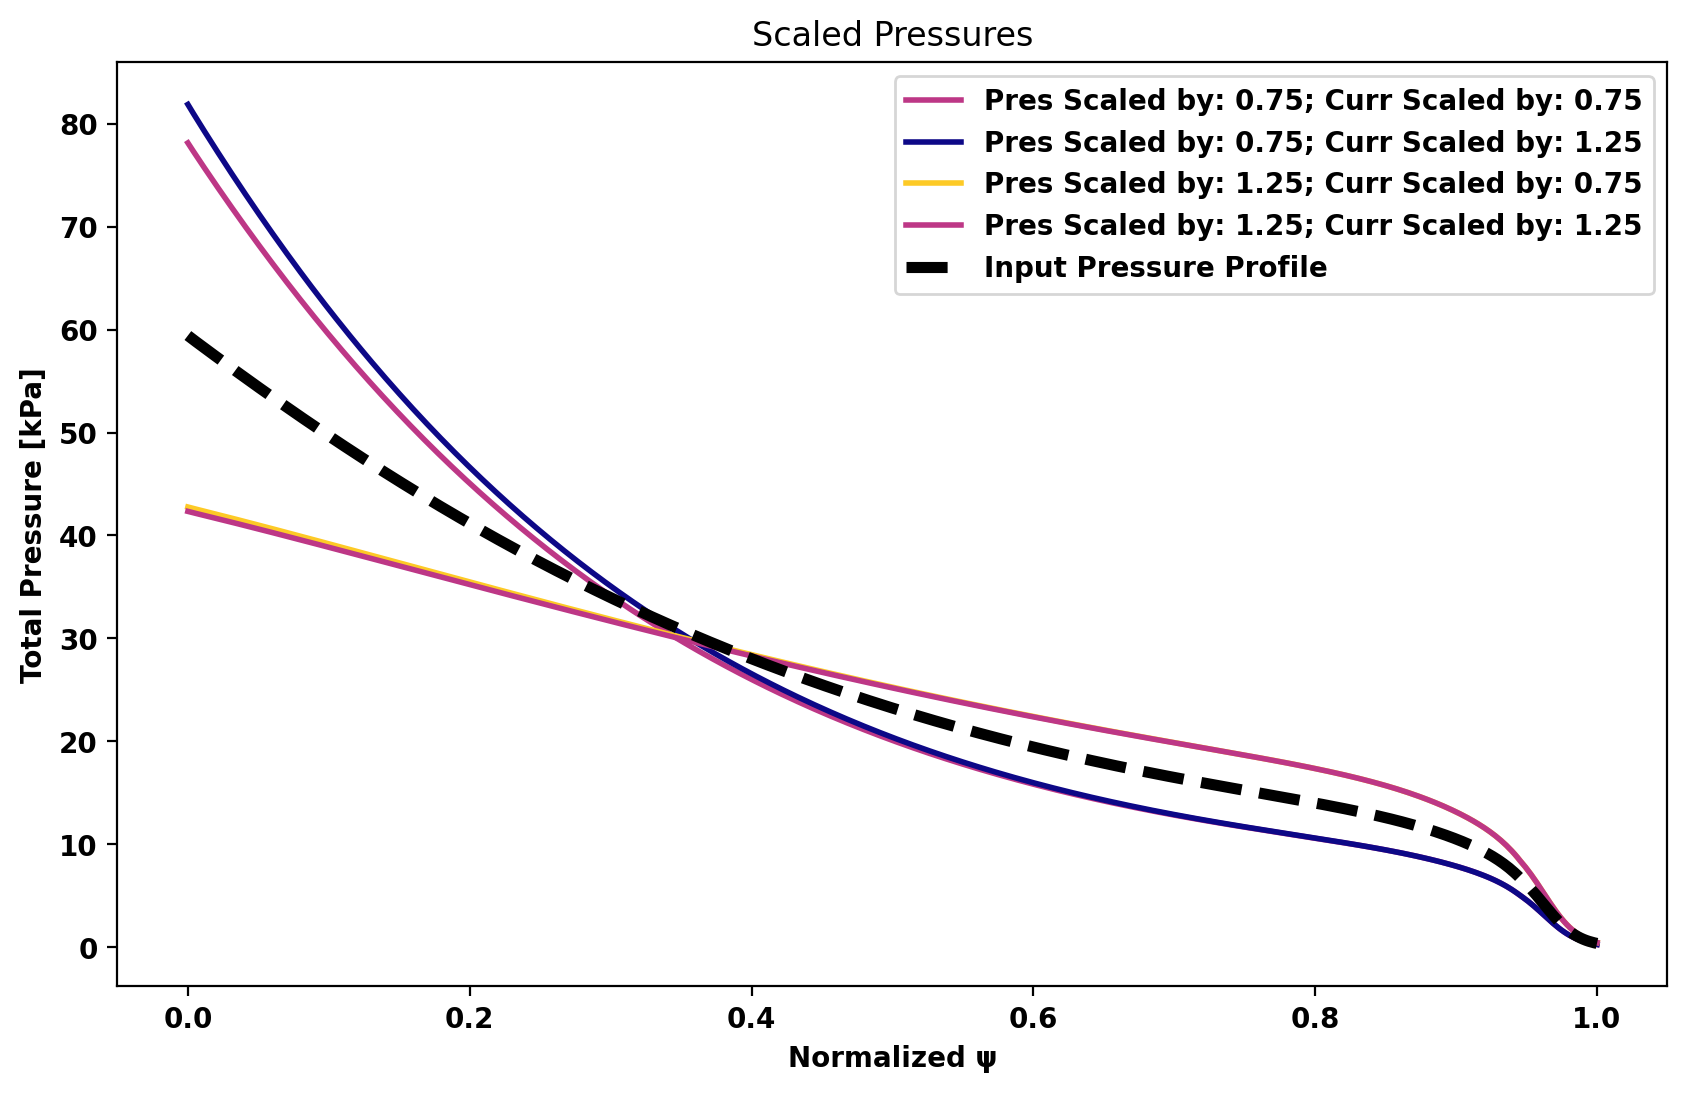

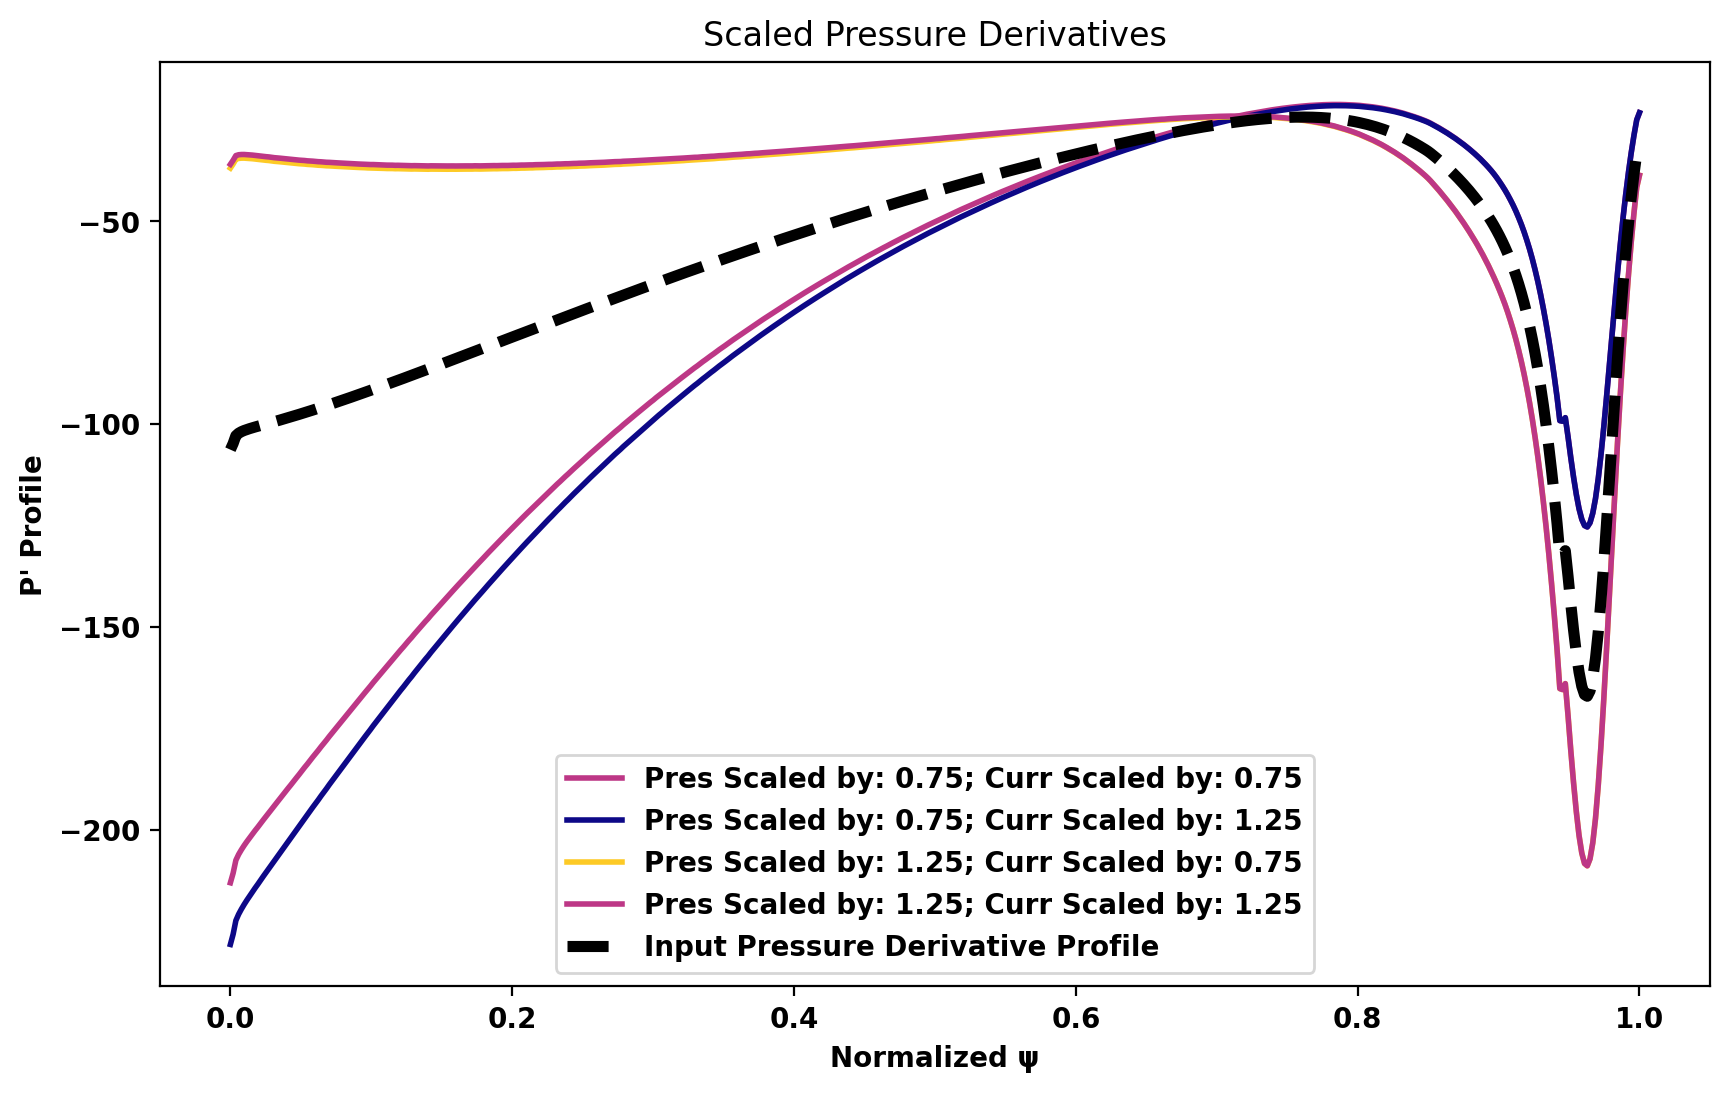

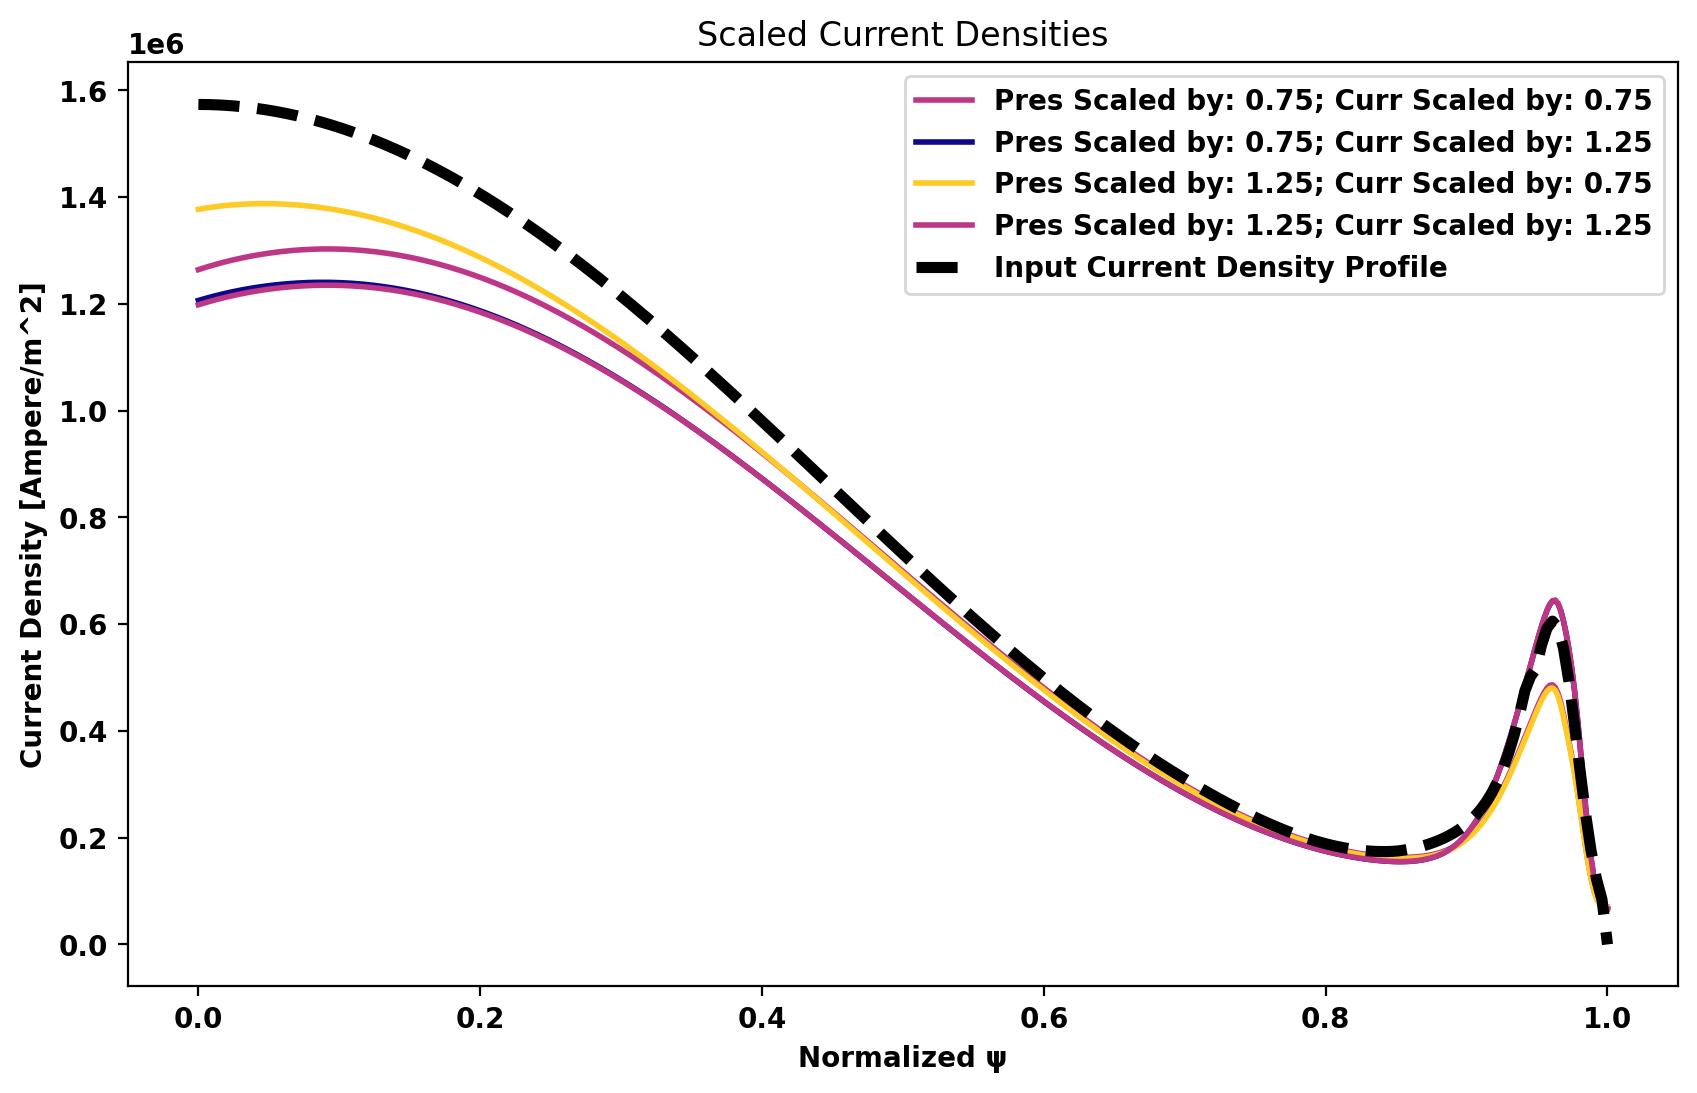

In [ ]:
varyped.plot_varyped_results(scaling_results, 
                             scaling_values, 
                             pfile_0=p_eq, 
                             gfile_0=g_eq)
